# Housing Price Prediction

This project builds a machine learning model to predict housing prices based on demographic and geographic features.

The workflow includes:
- Data exploration and visualization
- Data cleaning and preprocessing
- Feature engineering
- Model training and evaluation

The goal is to understand key drivers of housing prices and build a baseline predictive model.

## 1. Imports

Import necessary libraries for data manipulation, visualization, and modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## 2. Load Dataset

Load the housing dataset and inspect the first few rows to understand its structure.

In [2]:
data_path = "housing.csv"
df = pd.read_csv(data_path)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Initial Data Exploration

Understand the dataset by reviewing:
- Data types
- Missing values
- Summary statistics

This step helps identify potential cleaning and preprocessing needs.

In [3]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


## 4. Distribution of Numerical Features

Visualizing distributions helps identify:
- Skewness
- Outliers
- Feature scaling needs

This informs both preprocessing and model selection.

In [4]:
df["rooms_per_household"] = df["total_rooms"]/df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"]/df["total_rooms"]
df["population_per_household"] = df["population"]/df["households"]

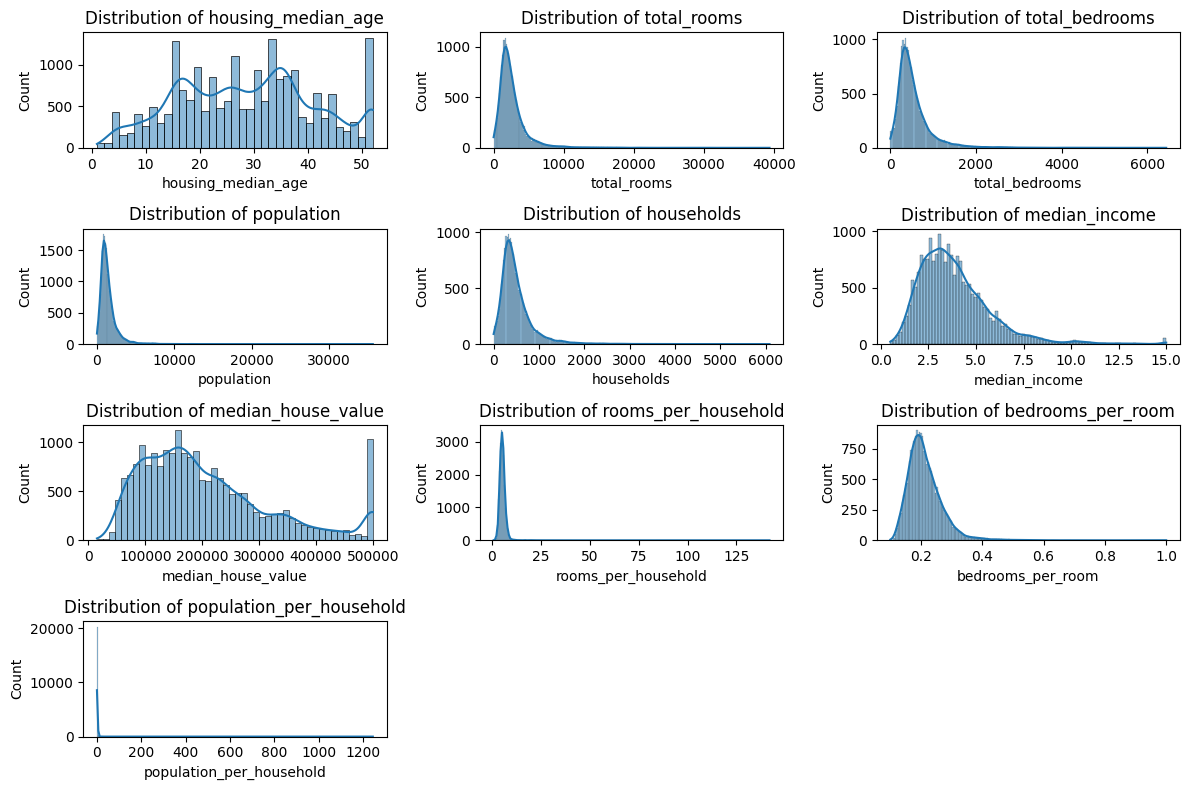

In [5]:
numeric_features = [
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "median_house_value",
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household",
]

plt.figure(figsize=(12, 8))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[feature], kde=True)
    plt.title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()

Something important to note: the median house value is capped at $500,000. Will perform a log transformation on the price column to compress the skew and make the model more proportional.

## 5. Correlation Analysis

A correlation heatmap highlights linear relationships between variables.

This helps:
- Identify features strongly related to the target
- Detect multicollinearity
- Guide feature selection

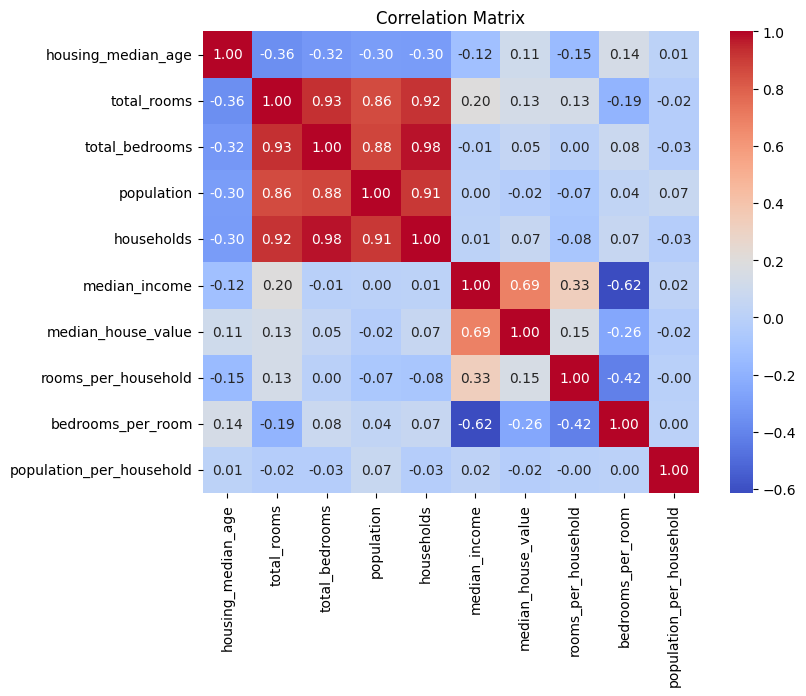

In [6]:
plt.figure(figsize=(8, 6))
corr = df[numeric_features].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## 6. Categorical Feature Analysis

Analyze how housing prices vary across different categories of ocean proximity.

This helps determine whether the categorical variable is informative for prediction.

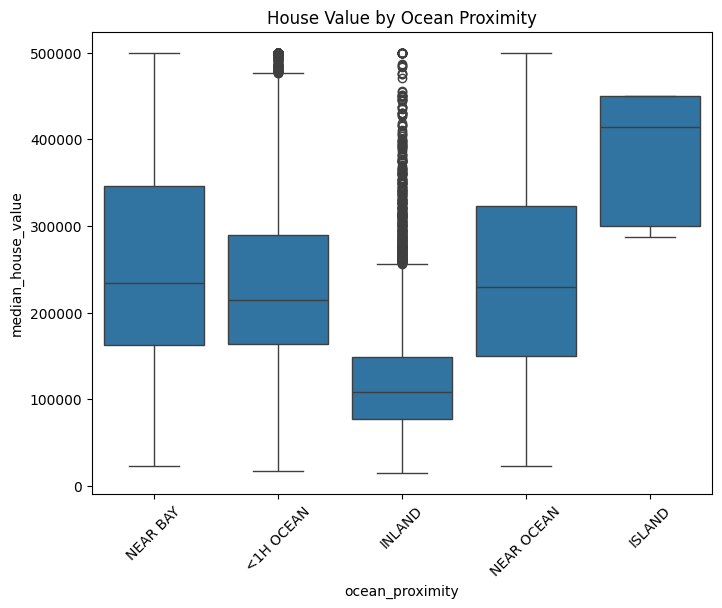

In [7]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="ocean_proximity", y="median_house_value", data=df)
plt.title("House Value by Ocean Proximity")
plt.xticks(rotation=45)
plt.show()

## 7. Feature Selection

Define the input features and target variable.

- Features include both numerical and categorical variables
- Target is the median house value

In [8]:
features = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "ocean_proximity",
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household",
]

target = "median_house_value"

X = df[features]
y = df[target]

## 8. Handling Missing Values

The `total_bedrooms` feature contains missing values.

We fill them using the median, which is robust to outliers and preserves the distribution.

In [17]:
X["total_bedrooms"] = X["total_bedrooms"].fillna(X["total_bedrooms"].median())
X["rooms_per_household"] = X["rooms_per_household"].fillna(X["rooms_per_household"].median())
X["bedrooms_per_room"] = X["bedrooms_per_room"].fillna(X["bedrooms_per_room"].median())
X["population_per_household"] = X["population_per_household"].fillna(X["population_per_household"].median())

/var/folders/80/q5zbz2x55cv8zcxjj9h4bvv80000gn/T/ipykernel_53163/3182910947.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["total_bedrooms"] = X["total_bedrooms"].fillna(X["total_bedrooms"].median())
/var/folders/80/q5zbz2x55cv8zcxjj9h4bvv80000gn/T/ipykernel_53163/3182910947.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["rooms_per_household"] = X["rooms_per_household"].fillna(X["rooms_per_household"].median())
/var/folders/80/q5zbz2x55cv8zcxjj9h4bvv80000gn/T/ipykernel_53163/3182910947.py:3: S

## 9. Preprocessing

Categorical variables need to be converted into numerical format.

We use One-Hot Encoding for `ocean_proximity` to avoid introducing ordinal relationships.

In [18]:
categorical_features = ["ocean_proximity"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

## 10. Model Pipeline

We build a pipeline to:
- Apply preprocessing
- Train a regression model

Using a pipeline ensures consistent transformations during training and inference.

In [19]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

boost = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor())
])

## 11. Train-Test Split

Split the dataset into training and testing sets to evaluate model performance on unseen data.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 12. Model Training

Fit the linear regression model on the training data.

In [21]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Now fit the linear regressioin model using the Gradient Boosting Regressor.

In [22]:
boost.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 13. Model Evaluation

Evaluate performance using Root Mean Squared Error (RMSE).

RMSE provides an interpretable measure of average prediction error in the same units as the target variable.

In [24]:
# Linear Regression
y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE on test set: {rmse:.2f}")
print(f"R^2 of Regression Model: {r2:.2f}")

RMSE on test set: 69126.81
R^2 of Regression Model: 0.64


In [25]:
# Gradient Boosting Regressor
pred = boost.predict(X_test)
root = root_mean_squared_error(y_test, pred)
r_square = r2_score(y_test, pred)

print(f"RMSE on test set: {root:.2f}")
print(f"R^2 of Regression Model: {r_square:.2f}")

RMSE on test set: 53463.74
R^2 of Regression Model: 0.78


## 14. Conclusion

This model provides a baseline for predicting housing prices using linear regression.

Potential improvements:
- Perform feature scaling or transformations
- Add feature engineering (e.g., ratios like rooms per household)
- Use cross-validation for more robust evaluation